# Runs aral sea model using PCR input

In [1]:
# setup imports
import sys
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path().resolve().parents[1]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import xarray as xr

import importlib
import src.aral as aral
importlib.reload(aral)
from src.constants import STATIONS_PCR

from src.paths import GRDC
from ewatercycle.observation.grdc import get_grdc_data


In [2]:
import xarray as xr

ds = xr.open_dataset("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/outputs/pcrglobwb/aral_discharge_master.nc")
print(ds)

importlib.reload(aral)

nachtnebel = pd.read_csv(
    Path("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/bathymetry/Nachtnebel_table.csv"),
    sep=";",
    decimal=",",
)

nachtnebel["Year"] = nachtnebel["Year"].astype(int)
nachtnebel = nachtnebel.set_index("Year")

<xarray.Dataset> Size: 52MB
Dimensions:     (time: 29586, station: 49, simulation: 9)
Coordinates:
  * time        (time) datetime64[ns] 237kB 1940-01-01 1940-01-02 ... 2020-12-31
  * station     (station) <U14 3kB 'Tyumen-aryk' 'Kazalinsk' ... 'Obizarang'
  * simulation  (simulation) <U47 2kB 'era5_default' ... 'cmip_mri-esm2_raw_p...
    lat         (station) float32 196B ...
    lon         (station) float32 196B ...
Data variables:
    discharge   (simulation, time, station) float32 52MB ...


In [3]:
ds.simulation.values

array(['era5_default', 'era5_chatly', 'era5_kazalinsk',
       'era5_uncalibrated', 'cmip_hist_miroc6',
       'cmip_mpi_esm1_2_hr_bias_corrected_parallel_runs',
       'cmip_mpi_esm1_2_hr_raw_parallel_runs',
       'cmip_mri-esm2_bias_corrected_parallel_runs',
       'cmip_mri-esm2_raw_parallel_runs'], dtype='<U47')

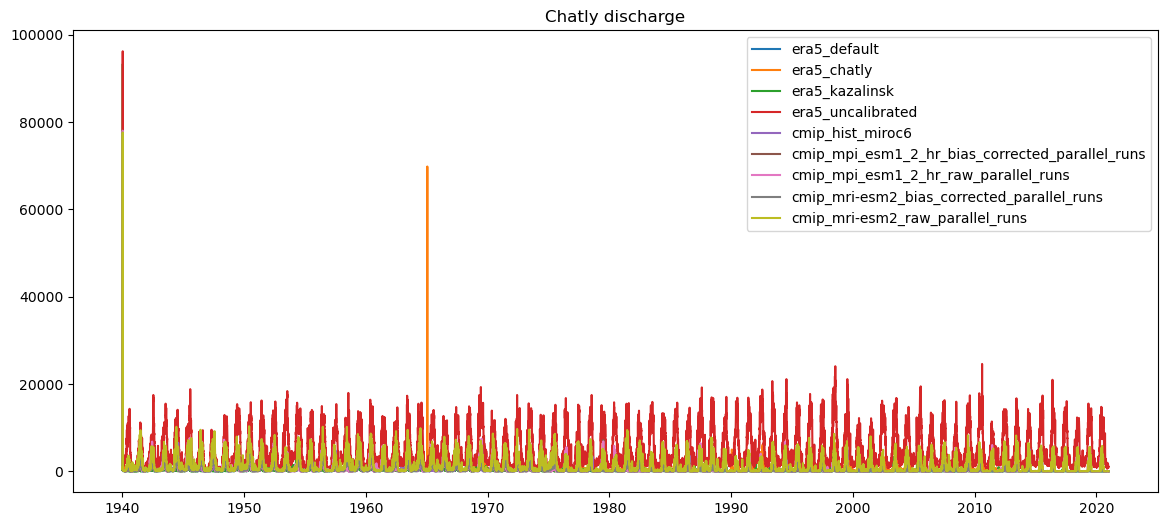

In [4]:
import matplotlib.pyplot as plt

da = ds["discharge"]

plt.figure(figsize=(14,6))

for sim_name in da.simulation.values:
    series = da.sel(simulation=sim_name, station="Chatly")

    plt.plot(series.time, series.values, label=sim_name)

plt.title("Chatly discharge")
plt.legend()
plt.show()

In [5]:
rivers = {}

for sim_name in da.simulation.values:

    rivers[sim_name] = {
        "Amu": aral.River(
            da.sel(simulation=sim_name, station="Chatly"),
            name=f"Amu - {sim_name}"
        ),
        "Syr": aral.River(
            da.sel(simulation=sim_name, station="Kazalinsk"),
            name=f"Syr - {sim_name}"
        )
    }

In [6]:
rivers

{'era5_default': {'Amu': <src.aral.River at 0x7f8d0950c770>,
  'Syr': <src.aral.River at 0x7f8d0950f740>},
 'era5_chatly': {'Amu': <src.aral.River at 0x7f8d09aca180>,
  'Syr': <src.aral.River at 0x7f8d0132dd00>},
 'era5_kazalinsk': {'Amu': <src.aral.River at 0x7f8d0132cbc0>,
  'Syr': <src.aral.River at 0x7f8d0130f620>},
 'era5_uncalibrated': {'Amu': <src.aral.River at 0x7f8d0133d9d0>,
  'Syr': <src.aral.River at 0x7f8d0133e0f0>},
 'cmip_hist_miroc6': {'Amu': <src.aral.River at 0x7f8d012f9460>,
  'Syr': <src.aral.River at 0x7f8d01363740>},
 'cmip_mpi_esm1_2_hr_bias_corrected_parallel_runs': {'Amu': <src.aral.River at 0x7f8d01363c50>,
  'Syr': <src.aral.River at 0x7f8d01363b30>},
 'cmip_mpi_esm1_2_hr_raw_parallel_runs': {'Amu': <src.aral.River at 0x7f8d0138c5c0>,
  'Syr': <src.aral.River at 0x7f8d0138caa0>},
 'cmip_mri-esm2_bias_corrected_parallel_runs': {'Amu': <src.aral.River at 0x7f8d0138cf80>,
  'Syr': <src.aral.River at 0x7f8d0138d400>},
 'cmip_mri-esm2_raw_parallel_runs': {'Amu': <

In [7]:
rivers["era5_kazalinsk"]["Syr"].Q

time
1940-01-01    0.056908
1940-01-02    0.056214
1940-01-03    0.059162
1940-01-04    0.055118
1940-01-05    0.048892
                ...   
2020-12-27    0.000967
2020-12-28    0.001653
2020-12-29    0.001675
2020-12-30    0.001110
2020-12-31    0.001766
Name: discharge, Length: 29586, dtype: float32

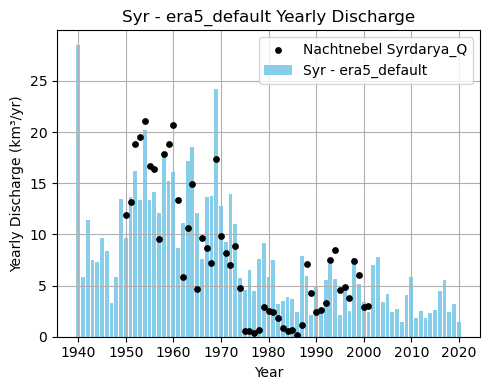

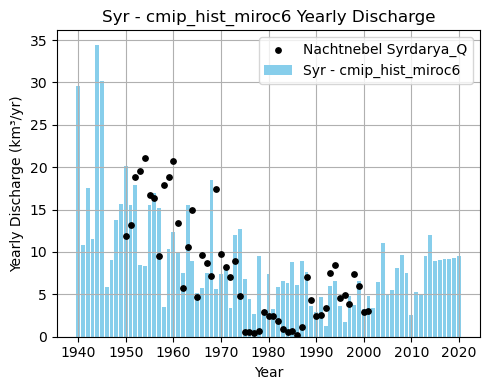

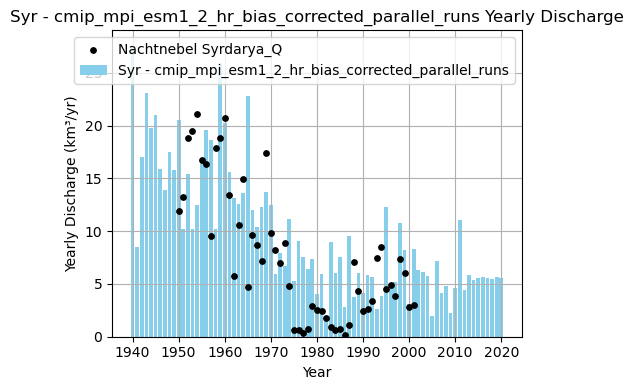

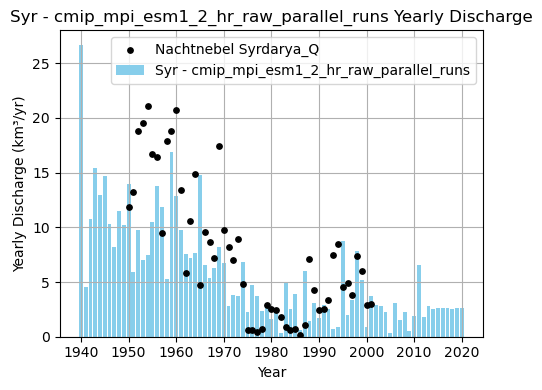

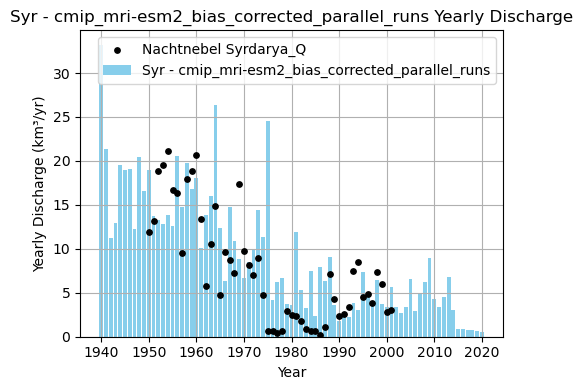

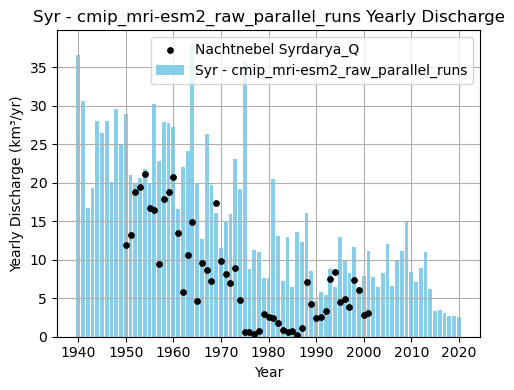

In [8]:
rivers["era5_default"]["Syr"].plot_yearly(
    observations=nachtnebel["Syrdarya_Q"],
    observation_label="Nachtnebel Syrdarya_Q",
)

rivers["cmip_hist_miroc6"]["Syr"].plot_yearly(
    observations=nachtnebel["Syrdarya_Q"],
    observation_label="Nachtnebel Syrdarya_Q",
)

rivers["cmip_mpi_esm1_2_hr_bias_corrected_parallel_runs"]["Syr"].plot_yearly(
    observations=nachtnebel["Syrdarya_Q"],
    observation_label="Nachtnebel Syrdarya_Q",
)

rivers["cmip_mpi_esm1_2_hr_raw_parallel_runs"]["Syr"].plot_yearly(
    observations=nachtnebel["Syrdarya_Q"],
    observation_label="Nachtnebel Syrdarya_Q",
)

rivers["cmip_mri-esm2_bias_corrected_parallel_runs"]["Syr"].plot_yearly(
    observations=nachtnebel["Syrdarya_Q"],
    observation_label="Nachtnebel Syrdarya_Q",
)

rivers["cmip_mri-esm2_raw_parallel_runs"]["Syr"].plot_yearly(
    observations=nachtnebel["Syrdarya_Q"],
    observation_label="Nachtnebel Syrdarya_Q",
)


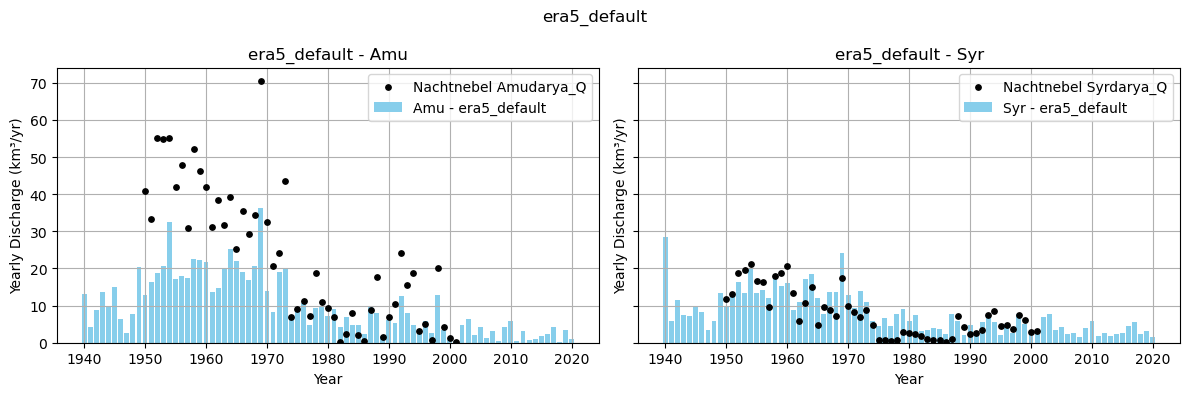

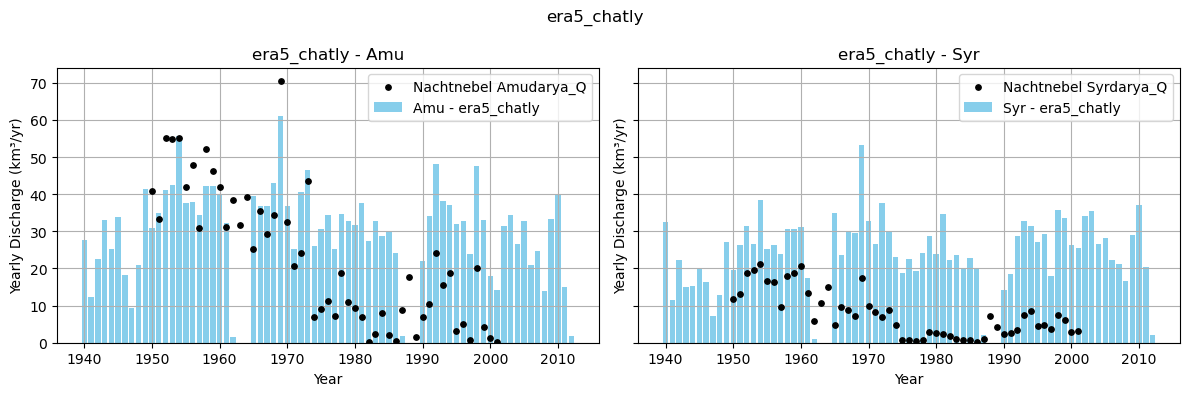

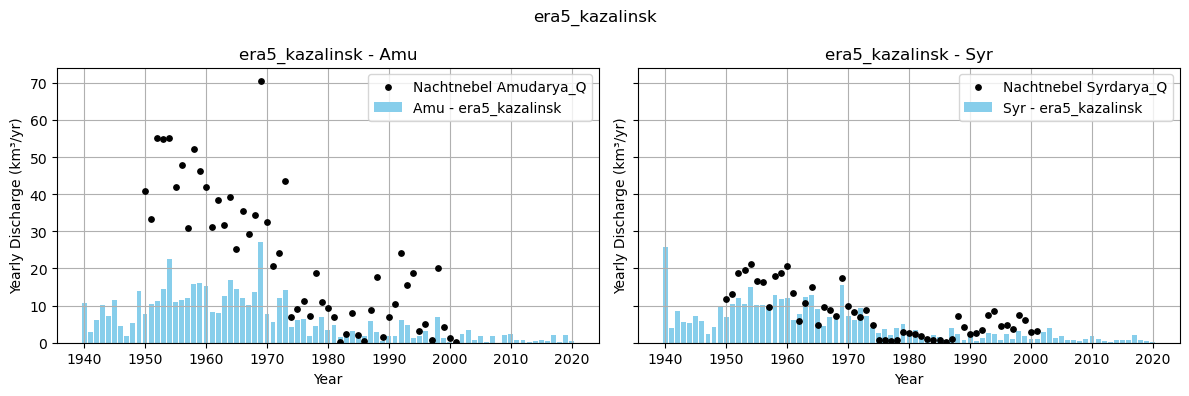

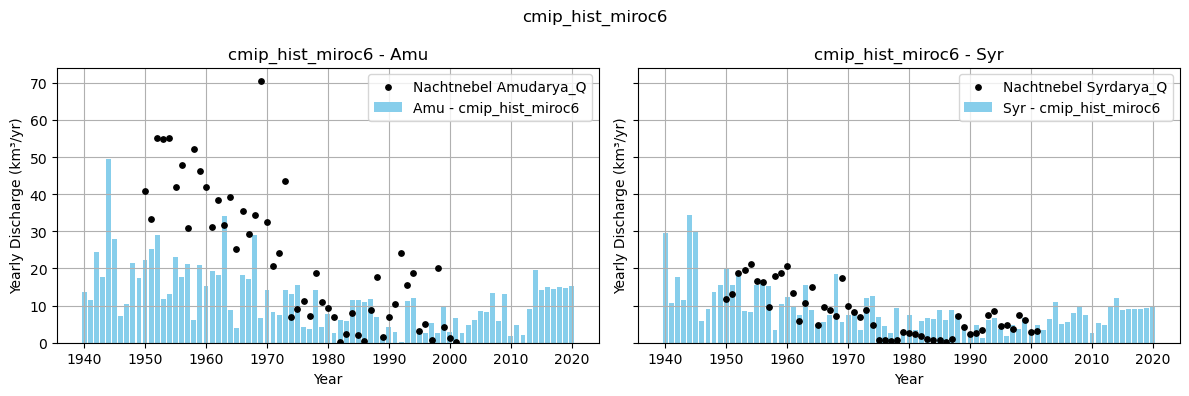

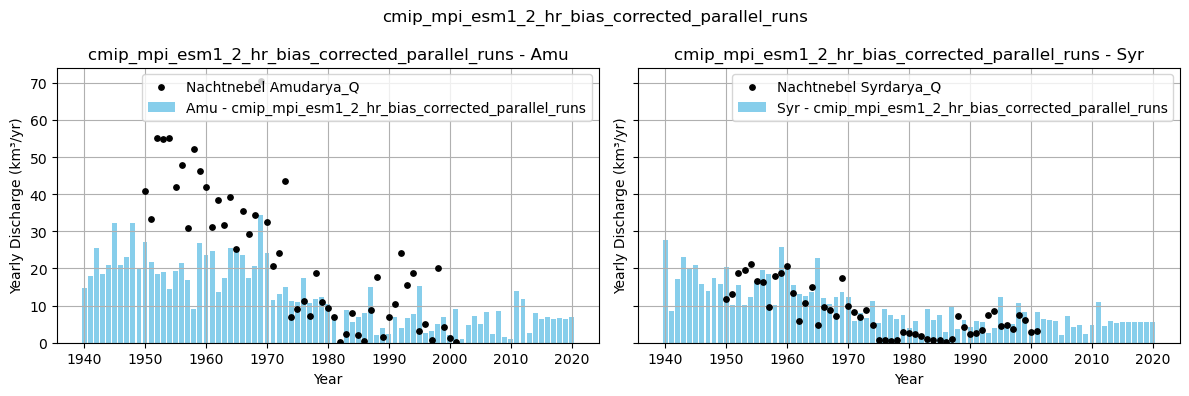

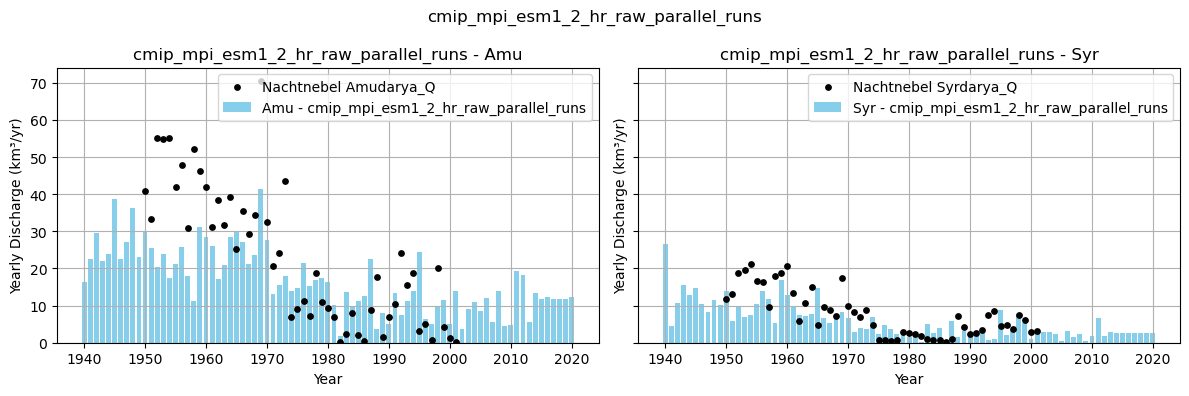

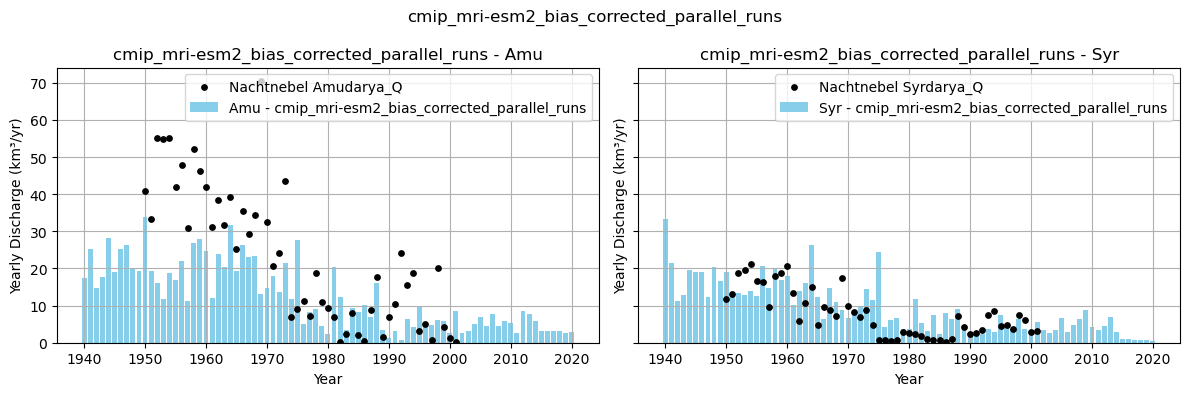

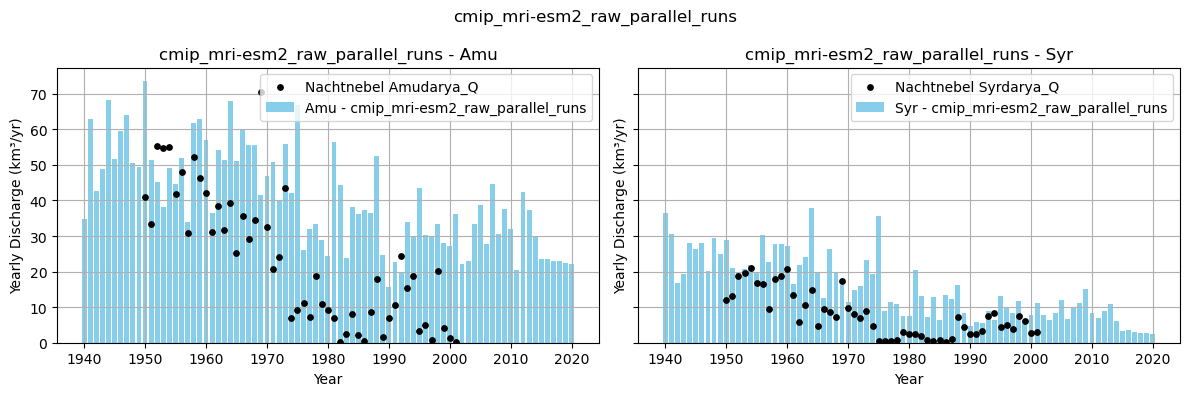

In [10]:
models = [
    "era5_default",
    "era5_chatly",
    "era5_kazalinsk",
    "cmip_hist_miroc6",
    "cmip_mpi_esm1_2_hr_bias_corrected_parallel_runs",
    "cmip_mpi_esm1_2_hr_raw_parallel_runs",
    "cmip_mri-esm2_bias_corrected_parallel_runs",
    "cmip_mri-esm2_raw_parallel_runs",
]


def plot_all(models):
    for m in models:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

        rivers[m]["Amu"].plot_yearly(
            ax=axes[0],
            observations=nachtnebel["Amudarya_Q"],
            observation_label="Nachtnebel Amudarya_Q",
        )
        axes[0].set_title(f"{m} - Amu")

        rivers[m]["Syr"].plot_yearly(
            ax=axes[1],
            observations=nachtnebel["Syrdarya_Q"],
            observation_label="Nachtnebel Syrdarya_Q",
        )
        axes[1].set_title(f"{m} - Syr")

        fig.suptitle(m)
        plt.tight_layout()
        plt.show()

plot_all(models)

In [ ]:
rivers["era5_default"]["Amu"].plot_yearly(
    observations=nachtnebel["Amudarya_Q"],
    observation_label="Nachtnebel Amudarya_Q",
)

In [ ]:
rivers["era5_default"]["Amu"].Q_raw

In [ ]:
# # Build one combined dataframe indexed by date
# df_i = df.copy()
# df_cmip_i = df_cmip.copy()

# df_i.index = pd.to_datetime(df_i.index)
# df_cmip_i.index = pd.to_datetime(df_cmip_i.index)

# df_combined = pd.concat(
#     {"era5": df_i, "cmip": df_cmip_i},
#     axis=1,
# ).sort_index()

# print(f"df_combined shape: {df_combined.shape}")
# print(f"period: {df_combined.index.min()} -> {df_combined.index.max()}")
# df_combined.head()

In [11]:
grdc_station_chatly = get_grdc_data(
    2817100, "1940-01-02T00:00Z", "2020-12-31T00:00Z", data_home=GRDC / "Daily"
)

In [12]:
grdc_station_kazalinsk = get_grdc_data(
    2316201, "1940-01-02T00:00Z", "2020-12-31T00:00Z", data_home=GRDC / "Daily"
)

In [13]:
grdc_station_chatly

<xarray.Dataset> Size: 199kB
Dimensions:              (time: 12418)
Coordinates:
  * time                 (time) datetime64[ns] 99kB 1940-01-02 ... 1973-12-31
    id                   int64 8B 2817100
Data variables:
    streamflow           (time) float64 99kB 494.0 494.0 470.0 ... 153.0 158.0
    area                 float64 8B 4.5e+05
    country              <U2 8B 'UZ'
    geo_x                float64 8B 59.7
    geo_y                float64 8B 42.28
    geo_z                float64 8B 72.0
    owneroforiginaldata  <U85 340B 'Initial dataset collected in the framewor...
    river_name           <U9 36B 'AMU DARYA'
    station_name         <U6 24B 'CHATLY'
    timezone             float64 8B nan
Attributes:
    title:          NA
    Conventions:    CF-1.7
    references:     grdc.bafg.de
    institution:    GRDC
    history:        Converted from 2817100_Q_Day.Cmd.txt of 2025-09-02 to net...
    missing_value:  -999.000

In [14]:
window_days = 365
min_periods = window_days // 2

conversion_factor = 86400 / 1e9  # m3/s to km3/day

rolled_rivers = {}

for sim, rivers_dict in rivers.items():
    rolled_rivers[sim] = {}

    for river_name, river_obj in rivers_dict.items():

        series = river_obj.Q_raw

        rolled = (
            series
            .rolling(window=window_days, min_periods=min_periods)
            .sum()
            * conversion_factor
        )

        rolled.name = f"{river_name}_{sim}"

        rolled_rivers[sim][river_name] = rolled

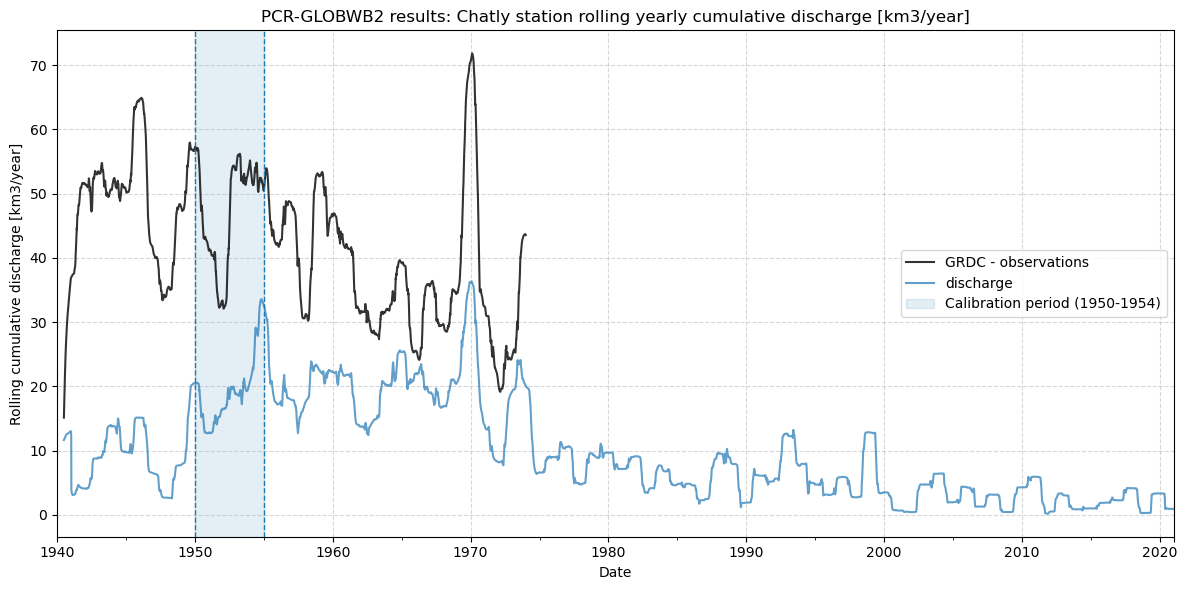

In [15]:
window_days = 365
min_periods = window_days // 2

conversion_factor = 86400 / 1e9  # m3/s to km3/day
grdc_station_chatly_roll_cum = (
    conversion_factor
    * grdc_station_chatly["streamflow"].rolling(time=window_days, min_periods=min_periods).sum().to_series()
)




riv1 = rivers["era5_default"]["Amu"].Q_raw .rolling(window=window_days, min_periods=min_periods).sum()* conversion_factor
# chatly_era5_roll_cum = conversion_factor * df_combined[("era5", "Chatly")].rolling(window=window_days, min_periods=min_periods).sum()
# chatly_cmip_roll_cum = conversion_factor * df_combined[("cmip", "Chatly")].rolling(window=window_days, min_periods=min_periods).sum()
# chatly_no_agri_roll_cum = conversion_factor * df_no_agri["Chatly"].rolling(window=window_days, min_periods=min_periods).sum()

cal_start = pd.Timestamp("1950-01-01")
cal_end = pd.Timestamp("1954-12-31")

plt.figure(figsize=(12, 6))
grdc_station_chatly_roll_cum.plot(label="GRDC - observations", color="black", alpha=0.8)
riv1.plot( color="tab:blue", alpha=0.7)


plt.axvspan(cal_start, cal_end, color="tab:blue", alpha=0.12, label=f"Calibration period ({cal_start.year}-{cal_end.year})")
plt.axvline(cal_start, color="tab:blue", linestyle="--", linewidth=1)
plt.axvline(cal_end, color="tab:blue", linestyle="--", linewidth=1)
plt.title("PCR-GLOBWB2 results: Chatly station rolling yearly cumulative discharge [km3/year]")
plt.xlabel("Date")
plt.ylabel("Rolling cumulative discharge [km3/year]")
plt.legend(loc = "center right")
plt.grid(alpha=0.5, linestyle="--")
plt.tight_layout()

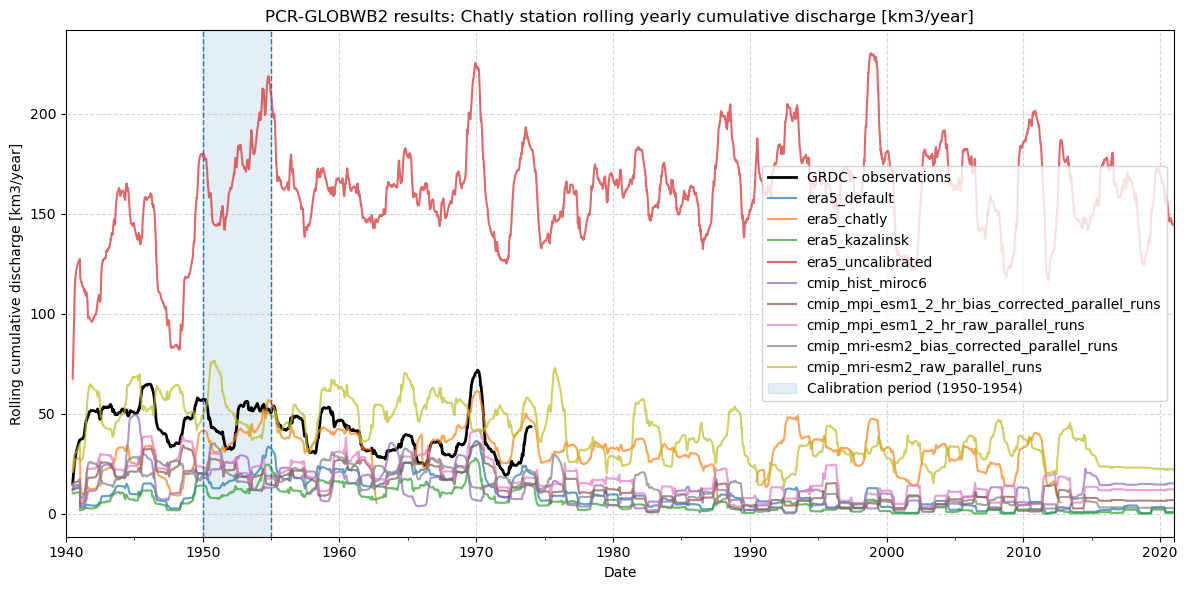

In [16]:
plt.figure(figsize=(12, 6))

# Observations
grdc_station_chatly_roll_cum.plot(
    label="GRDC - observations",
    color="black",
    alpha=1,
    linewidth=2
)

# All model simulations
for sim, rivers_dict in rolled_rivers.items():
    rivers_dict["Amu"].plot(
        label=sim,
        alpha=0.7
    )

# Calibration window
plt.axvspan(
    cal_start,
    cal_end,
    color="tab:blue",
    alpha=0.12,
    label=f"Calibration period ({cal_start.year}-{cal_end.year})"
)

plt.axvline(cal_start, color="tab:blue", linestyle="--", linewidth=1)
plt.axvline(cal_end, color="tab:blue", linestyle="--", linewidth=1)

plt.title("PCR-GLOBWB2 results: Chatly station rolling yearly cumulative discharge [km3/year]")
plt.xlabel("Date")
plt.ylabel("Rolling cumulative discharge [km3/year]")
plt.legend(loc="center right")
plt.grid(alpha=0.5, linestyle="--")
plt.tight_layout()

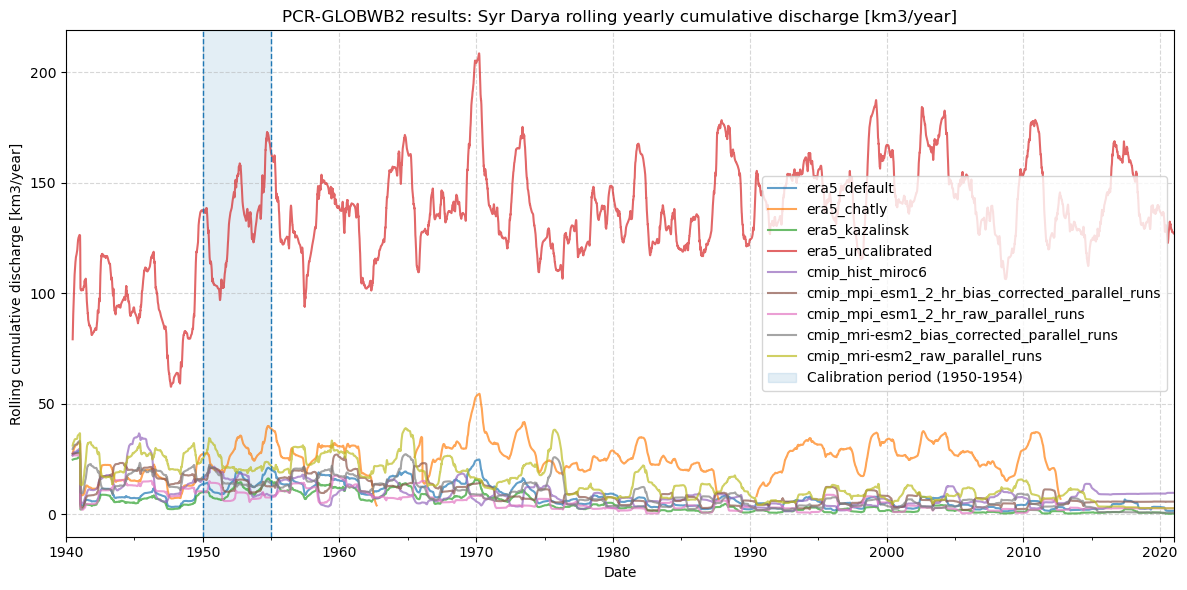

In [17]:
plt.figure(figsize=(12, 6))

# # Observations
# grdc_station_chatly_roll_cum.plot(
#     label="GRDC - observations",
#     color="black",
#     alpha=1,
#     linewidth=2
# )

# All model simulations
for sim, rivers_dict in rolled_rivers.items():
    rivers_dict["Syr"].plot(
        label=sim,
        alpha=0.7
    )

# Calibration window
plt.axvspan(
    cal_start,
    cal_end,
    color="tab:blue",
    alpha=0.12,
    label=f"Calibration period ({cal_start.year}-{cal_end.year})"
)

plt.axvline(cal_start, color="tab:blue", linestyle="--", linewidth=1)
plt.axvline(cal_end, color="tab:blue", linestyle="--", linewidth=1)

plt.title("PCR-GLOBWB2 results: Syr Darya rolling yearly cumulative discharge [km3/year]")
plt.xlabel("Date")
plt.ylabel("Rolling cumulative discharge [km3/year]")
plt.legend(loc="center right")
plt.grid(alpha=0.5, linestyle="--")
plt.tight_layout()

In [18]:
importlib.reload(aral)

nachtnebel = pd.read_csv(
    Path("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/bathymetry/Nachtnebel_table.csv"),
    sep=";",
    decimal=",",
)

nachtnebel["Year"] = nachtnebel["Year"].astype(int)
nachtnebel = nachtnebel.set_index("Year")


In [ ]:
# importlib.reload(aral)

# Amu_chatly = aral.River(df, q_col="Chatly", name="Amu Darya - Chatly")
# Amu_kerki = aral.River(df, q_col="Kerki", name="Amu Darya - Kerki")
# Syr_kaza = aral.River(df, q_col="Kazalinsk", name="Syr Darya - Kazalinsk")
# # Syr_kara = aral.River(df, q_col="Karaozek", name="Syr Darya - Karaozek")
# Syr_tyumen = aral.River(df, q_col="Tyumen-Aryk", name="Syr Darya - Tyumen Aryk")



# fig1 = Amu_kerki.plot_yearly(
#     return_fig=True,
#     observations=nachtnebel["Amudarya_Q"],
#     observation_label="Nachtnebel Amudarya_Q",
#     )
# fig2 = Amu_chatly.plot_yearly(
#     return_fig=True,
#     observations=nachtnebel["Amudarya_Q"],
#     observation_label="Observations", 
#     )

# fig3 = Syr_kaza.plot_yearly(return_fig=True,
#                             observations=nachtnebel["Syrdarya_Q"],
#     observation_label="Observations",
#     )
# import os

# os.makedirs("figures", exist_ok=True)
# fig1.savefig("figures/Amu_kerki_yearly_discharge.pdf", bbox_inches="tight")
# fig2.savefig("figures/Amu_chatly_yearly_discharge.pdf", bbox_inches="tight")
# fig3.savefig("figures/Syr_kaza_yearly_discharge.pdf", bbox_inches="tight")

NameError: name 'df' is not defined

In [ ]:
# Syr_kaza.plot_yearly()

In [23]:
aral_meteo = xr.open_dataset(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/ERA5/AralSea/1940-2020/work/diagnostic/script/Derived_Makkink_evspsblpot.nc"
)

# Initial settings
initial_volume = 1100
ahv_file = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/bathymetry/ahv_curve.csv"

# Run the model

def run_sim(sim_name, rivers_dict):
    return aral.run_connected_aral_model(
        aral_meteo,
        rivers=[rivers_dict["Amu"], rivers_dict["Syr"]],
        ahv_csv=ahv_file,
        V0_km3=initial_volume,
        start_time="1950-01-01",
        end_time="2014-12-31",
        tqdm_position=1,
    )


results = {
    sim: run_sim(sim, rivers_dict)
    for sim, rivers_dict in rivers.items()
}

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Found 1 NetCDF files in /home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/dahiti


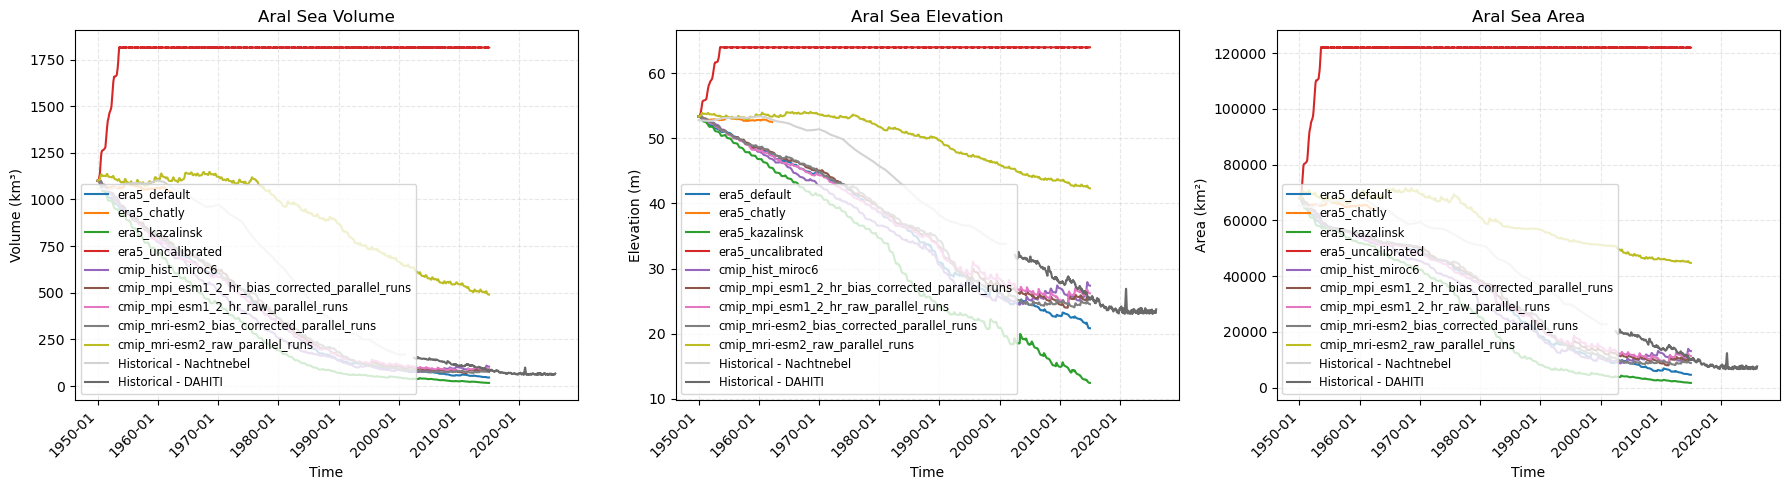

In [24]:
importlib.reload(aral)
observation = aral.make_obs()
aral.plot_aral_results(
    list(results.values()),
    labels=list(results.keys()),
    observations=observation,
)

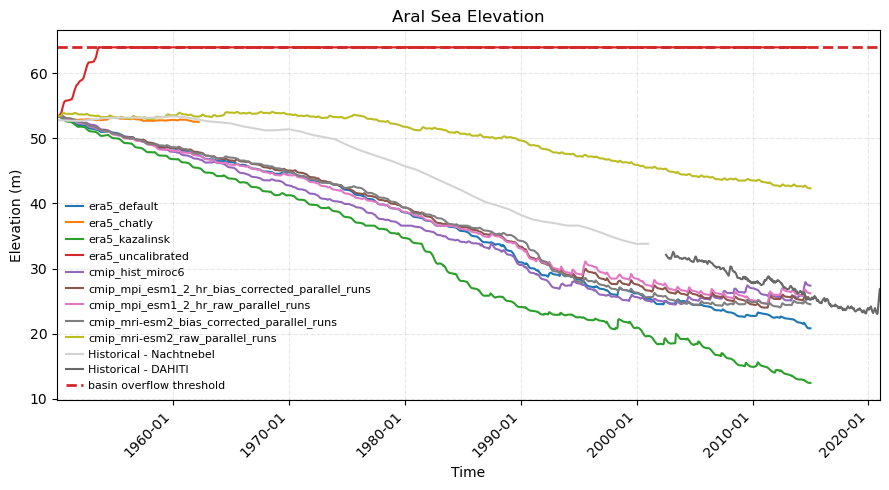

In [31]:
importlib.reload(aral)
aral.plot_aral_elevation(
    list(results.values()),
    labels=list(results.keys()),
    observations=observation,
)

In [ ]:
# df_aral_no_agri = aral.run_connected_aral_model(
#     aral_meteo,
#     rivers=[Amu_chatly_no_agri, Syr_kaza_no_agri],
#     ahv_csv=ahv_file,
#     V0_km3=initial_volume,
#     start_time="1950-01-01",
#     end_time="2020-12-31",
#     tqdm_position=1,
# )

In [ ]:
# observation = aral.make_obs()

In [ ]:
importlib.reload(aral)
aral.plot_aral_elevation(
    [df_aral, df_aral_no_agri],
    labels=[
        "Calibrated model (irrigation included)",
        "Calibrated parameters, (irrigation switched off)",
    ],
    observations=observation,
)

In [ ]:
aral.plot_aral_fluxes(df_aral)

In [21]:
from ewatercycle.esmvaltool.search import search_esgf

gcm_list = search_esgf(
    experiment="historical",
    frequency="day",
    variables=["pr", "tas"],
)




/tmp/ipykernel_266942/3285639101.py:3: UserWarning: The ESMValTool configuration option 'search_esgf' is not set to 'always'
this can lead to retrieving only subsets of the data you are interested in.
To set the configuration to always search on ESGF, do:
    from esmvalcore.config import CFG
    CFG['search_esgf'] = 'always'



In [15]:
list

{'E3SM-1-0': {'r1i1p1f1'},
 'MIROC6': {'r10i1p1f1',
  'r11i1p1f1',
  'r12i1p1f1',
  'r13i1p1f1',
  'r14i1p1f1',
  'r15i1p1f1',
  'r16i1p1f1',
  'r17i1p1f1',
  'r18i1p1f1',
  'r19i1p1f1',
  'r1i1p1f1',
  'r20i1p1f1',
  'r21i1p1f1',
  'r22i1p1f1',
  'r23i1p1f1',
  'r24i1p1f1',
  'r25i1p1f1',
  'r26i1p1f1',
  'r27i1p1f1',
  'r28i1p1f1',
  'r29i1p1f1',
  'r2i1p1f1',
  'r30i1p1f1',
  'r31i1p1f1',
  'r32i1p1f1',
  'r33i1p1f1',
  'r34i1p1f1',
  'r35i1p1f1',
  'r36i1p1f1',
  'r37i1p1f1',
  'r38i1p1f1',
  'r39i1p1f1',
  'r3i1p1f1',
  'r40i1p1f1',
  'r41i1p1f1',
  'r42i1p1f1',
  'r43i1p1f1',
  'r44i1p1f1',
  'r45i1p1f1',
  'r46i1p1f1',
  'r47i1p1f1',
  'r48i1p1f1',
  'r49i1p1f1',
  'r4i1p1f1',
  'r50i1p1f1',
  'r5i1p1f1',
  'r6i1p1f1',
  'r7i1p1f1',
  'r8i1p1f1',
  'r9i1p1f1'},
 'CAMS-CSM1-0': {'r2i1p1f1'},
 'NorCPM1': {'r10i1p1f1',
  'r11i1p1f1',
  'r12i1p1f1',
  'r13i1p1f1',
  'r14i1p1f1',
  'r15i1p1f1',
  'r16i1p1f1',
  'r17i1p1f1',
  'r18i1p1f1',
  'r19i1p1f1',
  'r1i1p1f1',
  'r20i1p1f1',
 

In [16]:
print(type(list))

<class 'dict'>


In [19]:
print(list.keys())

dict_keys(['E3SM-1-0', 'MIROC6', 'CAMS-CSM1-0', 'NorCPM1', 'CMCC-ESM2', 'MPI-ESM1-2-HR', 'CESM2-WACCM', 'GFDL-CM4', 'INM-CM4-8', 'MIROC-ES2L', 'CESM2-FV2', 'NESM3', 'EC-Earth3-ESM-1', 'KACE-1-0-G', 'NorESM2-MM', 'TaiESM1', 'BCC-CSM2-MR', 'AWI-ESM-1-1-LR', 'NorESM2-LM', 'FGOALS-f3-L', 'IITM-ESM', 'UKESM1-0-LL', 'EC-Earth3-AerChem', 'IPSL-CM5A2-INCA', 'ACCESS-ESM1-5', 'EC-Earth3', 'GFDL-ESM4', 'CanESM5', 'FGOALS-g3', 'CESM2', 'KIOST-ESM', 'CNRM-CM6-1', 'AWI-ESM-1-REcoM', 'SAM0-UNICON', 'INM-CM5-0', 'CMCC-CM2-SR5', 'IPSL-CM6A-LR', 'ICON-ESM-LR', 'ACCESS-CM2', 'EC-Earth3-Veg-LR', 'MPI-ESM1-2-LR', 'CESM2-WACCM-FV2', 'CNRM-CM6-1-HR', 'BCC-ESM1', 'CNRM-ESM2-1', 'MPI-ESM-1-2-HAM', 'EC-Earth3-CC', 'MRI-ESM2-0', 'CMCC-CM2-HR4', 'HadGEM3-GC31-LL', 'EC-Earth3-Veg', 'EC-Earth3-HR', 'HadGEM3-GC31-MM'])


In [ ]:
gcm_lis

TypeError: 'dict' object is not callable

In [23]:
import numpy as np

def arcdeg_to_km(lat, dlat=1.0, dlon=1.0):
    """
    Convert arc-degree grid spacing to km at a given latitude.

    Parameters
    ----------
    lat : float
        Latitude in degrees
    dlat : float
        Latitude spacing in degrees
    dlon : float
        Longitude spacing in degrees

    Returns
    -------
    dlat_km : float
        North-south distance in km
    dlon_km : float
        East-west distance in km at given latitude
    """

    R = 6371.0  # Earth radius in km

    # 1 degree latitude is constant everywhere
    km_per_deg_lat = (np.pi / 180) * R

    # 1 degree longitude depends on latitude
    km_per_deg_lon = km_per_deg_lat * np.cos(np.deg2rad(lat))

    return dlat * km_per_deg_lat, dlon * km_per_deg_lon

In [29]:
lat = 55

dlat_km, dlon_km = arcdeg_to_km(lat)

print(dlat_km, dlon_km)

111.19492664455873 63.77878976510199
